<a href="https://colab.research.google.com/github/hcopley/st_542_ml_systematic_review/blob/main/SuperLearnerD2V.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SuperLearner Ensemble On Doc2Vec Data (Heather, Jarrett, Andras)

## Install packages and load data

In [ ]:
# Install the SuperLearner package
install.packages("SuperLearner")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘bitops’, ‘gtools’, ‘caTools’, ‘iterators’, ‘gplots’, ‘foreach’, ‘ROCR’, ‘nnls’, ‘gam’, ‘cvAUC’




In [ ]:
# Install other packages
install.packages(c("xgboost", "randomForest", "e1071", "glmnet", "ranger"))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
if (!require("kernlab")) install.packages("kernlab")
library(kernlab)

Loading required package: kernlab

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘kernlab’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
# Load libraries
library(SuperLearner)
library(xgboost)
library(randomForest)
library(e1071)
#library(kernlab)
library(glmnet)

Loading required package: nnls

Loading required package: gam

Loading required package: splines

Loading required package: foreach

Loaded gam 1.22-7


Super Learner

Version: 2.0-40

Package created on 2025-12-14


randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.

Loading required package: Matrix

Loaded glmnet 4.1-10



In [ ]:
# Set seed to ensure reproducibility
set.seed(542)

In [ ]:

# Load the data
data <- readRDS("doc2vec_dtst.rds")
valid_folds <- readRDS("cv_folds.rds")

In [ ]:

# Separate features (X) and label (Y)
Y <- data[, 2]
X <- data[, -2]

## Individual Base Learners

In [ ]:
# Define the learners
library_names <- c("SL.glm",       # Logistic Regression
                   "SL.svm",       # Support Vector Machine
                   "SL.xgboost",   # XGBoost
                   "SL.ranger",    # Random Forest
                   "SL.naivebayes")# Naive Bayes

# Customize SVM for classification if needed
SL.svm.class <- function(..., kernel = "radial") SL.svm(..., kernel = kernel)


In [ ]:
# Run CV.SuperLearner with Logistic Regression only
# SL.glm is the wrapper for logistic regression
cv_sl_logic <- CV.SuperLearner(
  Y = Y,
  X = X,
  family = binomial(),
  SL.library = "SL.glm",
  cvControl = list(
    V = 5,
    validRows = valid_folds # Uses external 5-fold list
  )
)

# View performance results
summary(cv_sl_logic)


Call:  
CV.SuperLearner(Y = Y, X = X, family = binomial(), SL.library = "SL.glm",  
    cvControl = list(V = 5, validRows = valid_folds)) 

Risk is based on: Mean Squared Error

All risk estimates are based on V =  5 

     Algorithm      Ave        se      Min      Max
 Super Learner 0.062153 0.0015909 0.053937 0.070694
   Discrete SL 0.062153 0.0015909 0.053937 0.070694
    SL.glm_All 0.062153 0.0015909 0.053937 0.070694

In [ ]:
# Run CV.SuperLearner with SVM only
# SL.ksvm is the standard SVM wrapper in SuperLearner
cv_sl_svm <- CV.SuperLearner(
  Y = Y,
  X = X,
  family = binomial(),
  SL.library = "SL.ksvm",
  cvControl = list(
    V = 5,
    validRows = valid_folds # Use external 5-fold list
  )
)

# Review the risk/error for the SVM model
summary(cv_sl_svm)

Number of covariates in All is: 101



 Setting default kernel parameters  
maximum number of iterations reached 0.01127844 0.008878934

CV SL.ksvm.fast_All

Number of covariates in All is: 101



 Setting default kernel parameters  
maximum number of iterations reached 0.0127753 0.01020128

CV SL.ksvm.fast_All

Number of covariates in All is: 101



...

 Setting default kernel parameters  
maximum number of iterations reached 0.01104582 0.008632324

CV SL.ksvm.fast_All

Non-Negative least squares convergence: TRUE



 Setting default kernel parameters  
maximum number of iterations reached 0.01207008 0.009671247

full SL.ksvm.fast_All




Call:  
CV.SuperLearner(Y = Y, X = as.data.frame(scale(X)), family = binomial(),  
    SL.library = "SL.ksvm.fast", verbose = TRUE, cvControl = list(V = 5,  
        validRows = valid_folds)) 

Risk is based on: Mean Squared Error

All risk estimates are based on V =  5 

        Algorithm      Ave        se      Min      Max
    Super Learner 0.062509 0.0016704 0.055378 0.069404
      Discrete SL 0.062509 0.0016704 0.055378 0.069404
 SL.ksvm.fast_All 0.062509 0.0016704 0.055378 0.069404

In [ ]:
# Run CV.SuperLearner with XGBoost only
cv_sl_xgb <- CV.SuperLearner(
  Y = Y,
  X = X,
  family = binomial(),
  SL.library = "SL.xgboost",
  cvControl = list(
    V = 5,
    validRows = valid_folds # Use external 5-fold list
  )
)

# View the XGBoost risk results
summary(cv_sl_xgb)

In [ ]:
# Run CV.SuperLearner with Random Forest only
cv_sl_rf <- CV.SuperLearner(
  Y = Y,
  X = X,
  family = binomial(),
  SL.library = "SL.randomForest",
  cvControl = list(
    V = 5,
    validRows = valid_folds # Uses your external 5-fold list
  )
)

# View the Random Forest risk results
summary(cv_sl_rf)


Call:  
CV.SuperLearner(Y = Y, X = X, family = binomial(), SL.library = "SL.randomForest",  
    cvControl = list(V = 5, validRows = valid_folds)) 

Risk is based on: Mean Squared Error

All risk estimates are based on V =  5 

           Algorithm      Ave        se      Min      Max
       Super Learner 0.061219 0.0014644 0.055988 0.067757
         Discrete SL 0.061219 0.0014644 0.055988 0.067757
 SL.randomForest_All 0.061219 0.0014644 0.055988 0.067757

In [ ]:
Run CV.SuperLearner with Naive Bayes only
cv_sl_nb <- CV.SuperLearner(
  Y = Y,
  X = X,
  family = binomial(),
  SL.library = "SL.naiveBayes",
  cvControl = list(
    V = 5,
    validRows = valid_folds # Use external 5-fold list
  )
)

# View the Naive Bayes risk results
summary(cv_sl_nb)

## SuperLearner Ensemble

In [ ]:
# Run CV.SuperLearner with custom folds
# This fits SL, then evaluates it using the 5-fold structure in valid_folds
set.seed(542) # For reproducibility
cv_sl <- CV.SuperLearner(Y = Y,
                         X = X,
                         family = binomial(), # Or gaussian() for regression
                         SL.library = library_names[!library_names %in% c("SL.svm", "SL.naivebayes")], # Remove SL.svm due to 'infeasible nu' error and SL.naivebayes for 'object not found'
                         cvControl = list(V = 5, validRows = valid_folds),
                         innerCvControl = list(list(V = 5)),
                         verbose = TRUE)

Warning message in CV.SuperLearner(Y = Y, X = X, family = binomial(), SL.library = library_names[!library_names %in% :
“Only a single innerCvControl is given, will be replicated across all cross-validation split calls to SuperLearner”
Number of covariates in All is: 101

CV SL.glm_All

CV SL.xgboost_All



Growing trees.. Progress: 61%. Estimated remaining time: 19 seconds.


CV SL.ranger_All

Number of covariates in All is: 101

CV SL.glm_All

CV SL.xgboost_All



Growing trees.. Progress: 65%. Estimated remaining time: 16 seconds.


CV SL.ranger_All

Number of covariates in All is: 101

CV SL.glm_All

CV SL.xgboost_All



...

CV SL.ranger_All

Number of covariates in All is: 101

CV SL.glm_All

CV SL.xgboost_All



Growing trees.. Progress: 66%. Estimated remaining time: 16 seconds.


CV SL.ranger_All

Non-Negative least squares convergence: TRUE

full SL.glm_All

full SL.xgboost_All



Growing trees.. Progress: 46%. Estimated remaining time: 36 seconds.
Growing trees.. Progress: 92%. Estimated remaining time: 5 seconds.


full SL.ranger_All




Call:  
CV.SuperLearner(Y = Y, X = X, family = binomial(), SL.library = library_names[!library_names %in%  
    c("SL.svm", "SL.naivebayes")], verbose = TRUE, cvControl = list(V = 5,  
    validRows = valid_folds), innerCvControl = list(list(V = 5))) 

Risk is based on: Mean Squared Error

All risk estimates are based on V =  5 

      Algorithm      Ave        se      Min      Max
  Super Learner 0.059748 0.0016299 0.052880 0.067350
    Discrete SL 0.062947 0.0017295 0.056375 0.070694
     SL.glm_All 0.062153 0.0015909 0.053937 0.070694
 SL.xgboost_All 0.063045 0.0017834 0.056375 0.071182
  SL.ranger_All 0.061348 0.0014647 0.056109 0.068016


Loading required namespace: ggplot2

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the SuperLearner package.
  Please report the issue to the authors.”


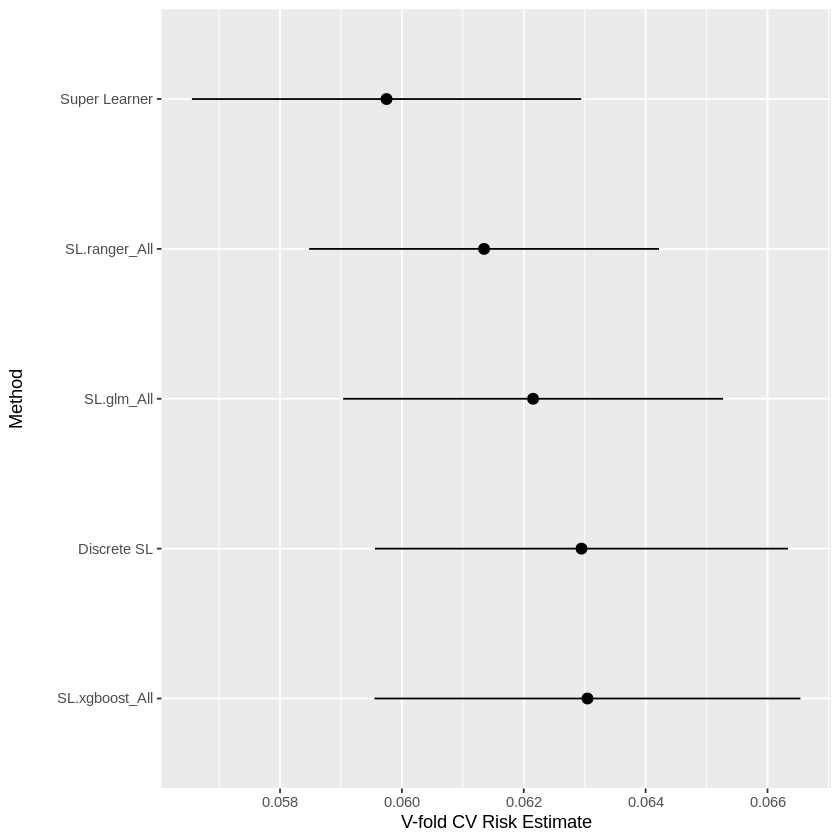

In [ ]:
# Check the results
print(summary(cv_sl))
plot(cv_sl)

In [ ]:
print(coef(cv_sl))

      SL.glm_All SL.xgboost_All SL.ranger_All
Fold1  0.2857147      0.4690101     0.2452752
Fold2  0.3003045      0.4980835     0.2016120
Fold3  0.2898302      0.4778532     0.2323166
Fold4  0.3010466      0.4689527     0.2300007
Fold5  0.3303353      0.4321273     0.2375374


In [ ]:
# Run the SuperLearner fit the 5 pre-defined lists from cv_folds.rds
sl_fit <- SuperLearner(
  Y = Y,
  X = X,
  family = binomial(),
  SL.library = library_names[!library_names %in% c("SL.svm", "SL.naivebayes")],
  cvControl = list(
    V = 5,
    validRows = valid_folds
  )
)

# View the final weights
print(sl_fit)

# Print the weights
final_weights <- sl_fit$coef
print(final_weights)

Growing trees.. Progress: 37%. Estimated remaining time: 51 seconds.
Growing trees.. Progress: 75%. Estimated remaining time: 20 seconds.
Growing trees.. Progress: 39%. Estimated remaining time: 47 seconds.
Growing trees.. Progress: 78%. Estimated remaining time: 17 seconds.
Growing trees.. Progress: 36%. Estimated remaining time: 55 seconds.
Growing trees.. Progress: 72%. Estimated remaining time: 23 seconds.
Growing trees.. Progress: 39%. Estimated remaining time: 49 seconds.
Growing trees.. Progress: 76%. Estimated remaining time: 20 seconds.
Growing trees.. Progress: 37%. Estimated remaining time: 53 seconds.
Growing trees.. Progress: 73%. Estimated remaining time: 22 seconds.
Growing trees.. Progress: 27%. Estimated remaining time: 1 minute, 22 seconds.
Growing trees.. Progress: 55%. Estimated remaining time: 49 seconds.
Growing trees.. Progress: 86%. Estimated remaining time: 15 seconds.

Call:  
SuperLearner(Y = Y, X = X, family = binomial(), SL.library = library_names[!library_